# Projet de détection de fraude à l’assurance automobile

C'est un projet de détection de fraudes dans les demandes d’indemnisation liées à l’assurance automobile.

Le dataset utilisé contient des informations relatives :
- aux assurés,
- aux véhicules,
- aux contrats d’assurance, 
- ainsi qu’aux déclarations de sinistre.

A partir de ces données d'entrée, on determine si la demande est fraudulause ou pas.

Donc, l’objectif est de construire un pipeline complet de Machine Learning capable de prédire si une demande d’indemnisation est frauduleuse ou non.

On  est face à un problème de classification binaire :
- `0` : demande non frauduleuse ;
- `1` : demande frauduleuse.

## Import des librairies

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score, recall_score, f1_score
from sklearn.metrics import roc_curve

## Chargement du dataset



In [7]:
import os

print(os.getcwd())

/Users/alibahabakar/Projects/insurance-fraud-detection/notebook


In [ ]:
path = "../input/fraud_oracle.csv"
df = pd.read_csv(path)



../input/fraud_oracle.csv


## Analyse exploratoire des données (EDA)

In [ ]:
print("\nInformations sur les données:")
print(f" Shape : {df.shape}")
print("-"*70)
print(df.info())




Informations sur les données:
 Shape : (15420, 33)
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  s

In [24]:
print("\nStatistiques descriptives:")
print(df.describe())



Statistiques descriptives:
        WeekOfMonth  WeekOfMonthClaimed  ...  DriverRating          Year
count  15420.000000        15420.000000  ...  15420.000000  15420.000000
mean       2.788586            2.693969  ...      2.487808   1994.866472
std        1.287585            1.259115  ...      1.119453      0.803313
min        1.000000            1.000000  ...      1.000000   1994.000000
25%        2.000000            2.000000  ...      1.000000   1994.000000
50%        3.000000            3.000000  ...      2.000000   1995.000000
75%        4.000000            4.000000  ...      3.000000   1996.000000
max        5.000000            5.000000  ...      4.000000   1996.000000

[8 rows x 9 columns]


### Valeurs manquantes ?

In [13]:
print("\nVérifier si présence de valeurs nulles:")
print(df.isna().sum().sum())

fraud_rate = df['FraudFound_P'].mean() * 100
print(f"Taux de fraude : {fraud_rate:.2f}%")
print(f"Taux de non fraude : {100 - fraud_rate:.2f}%")


Vérifier si présence de valeurs nulles:
0
Taux de fraude : 5.99%
Taux de non fraude : 94.01%


In [ ]:

print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

df['FraudFound_P'].value_counts(normalize=True) * 100

Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', '

### Visualisation

/var/folders/r5/v0cjy_bn5c90xy_rgw6wkc5w0000gn/T/ipykernel_7449/1074836719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])


Text(0, 0.5, 'Âge')

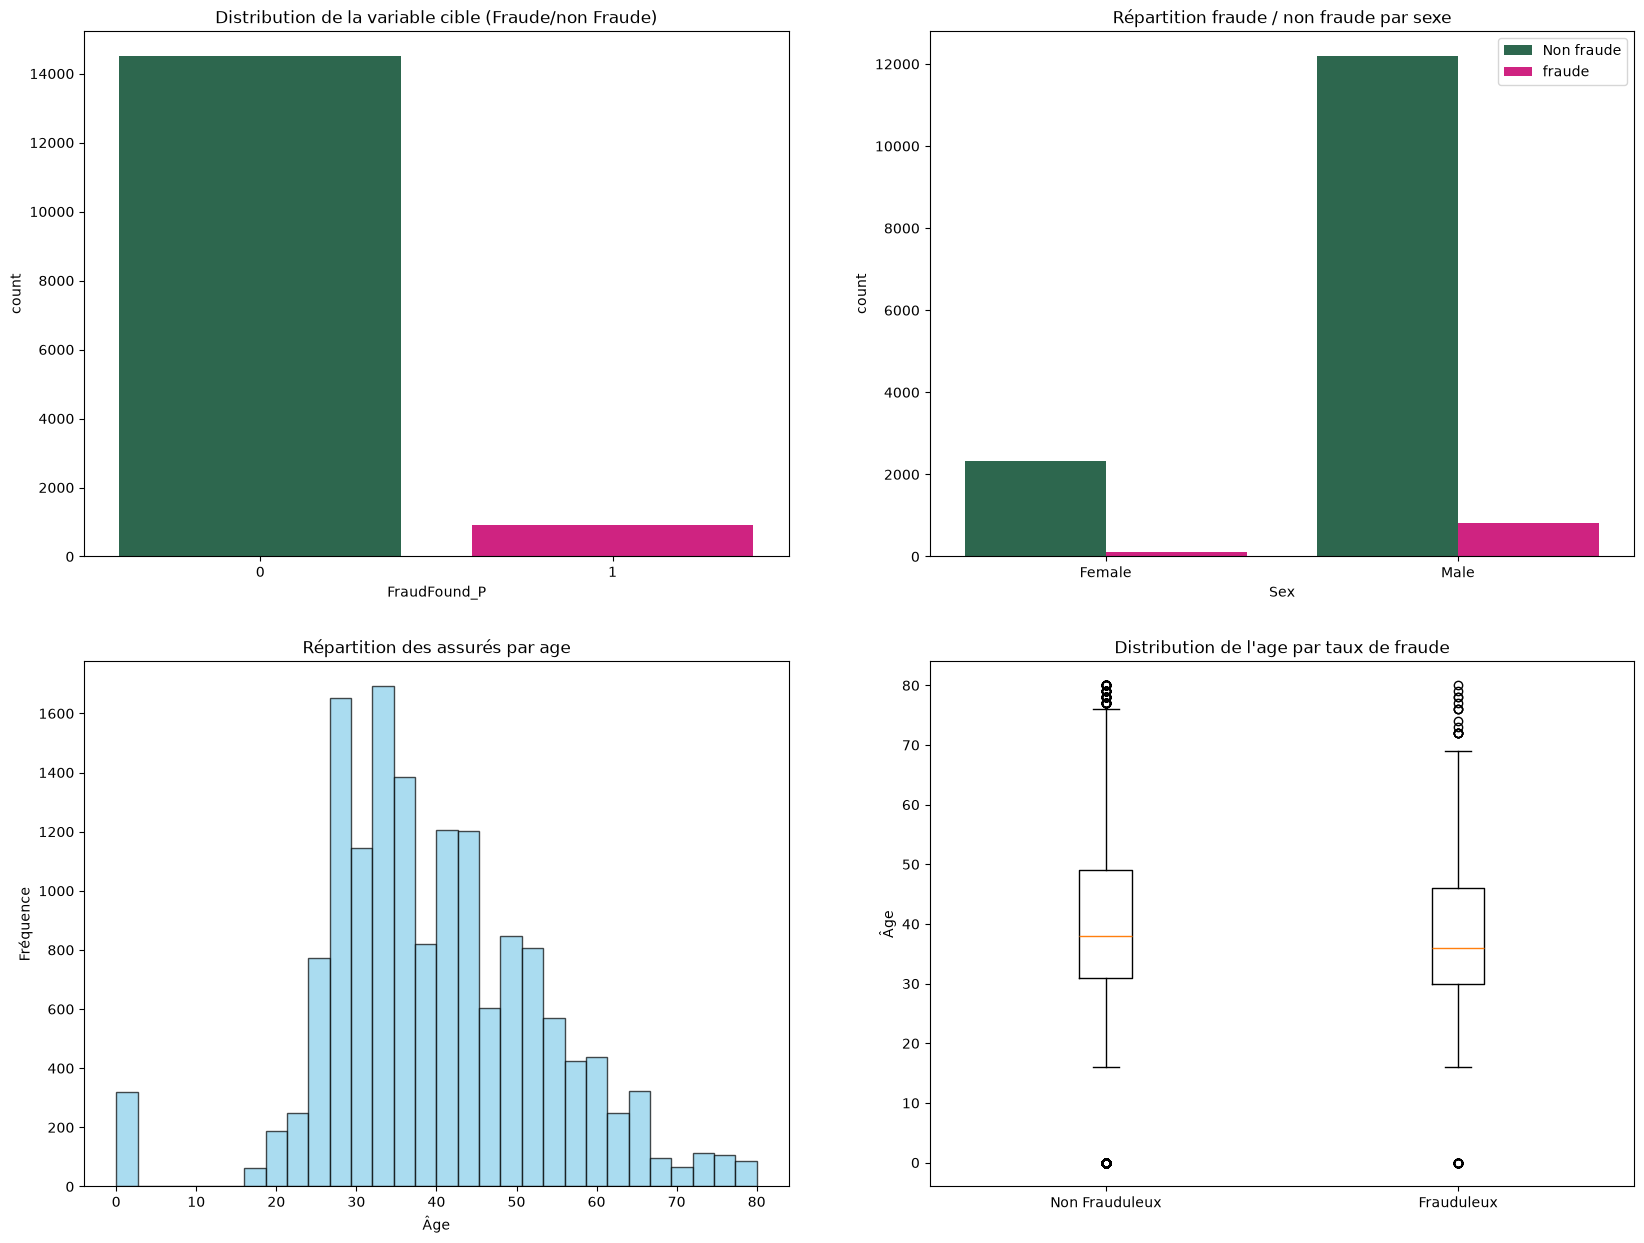

In [15]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(2, 2, 1)
survival_counts = df['FraudFound_P'].value_counts()
sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])
plt.title('Distribution de la variable cible (Fraude/non Fraude)')

# 2. Taux de fraude par sexe
plt.subplot(2, 2, 2)
sns.countplot(x='Sex', hue='FraudFound_P',  data=df, palette=["#23714F","#EB0784"])
plt.title('Répartition fraude / non fraude par sexe')
plt.legend(['Non fraude', 'fraude'])
plt.xticks(rotation=0)


# 3. Distribution de l'âge
plt.subplot(2, 2, 3)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Répartition des assurés par age')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(2, 2, 4)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title("Distribution de l'age par taux de fraude")
plt.ylabel('Âge')







In [28]:
# Valeur age à 0
print(f"Nombre de lignes ou âge est à 0 : {(df["Age"] == 0).sum()} soit {round((df["Age"] == 0).sum() * 100 /df.shape[0], 2)} %")



Nombre de lignes ou âge est à 0 : 320 soit 2.08 %


La variable Age contient des valeurs égales à 0 (~2% du dataset).
On suppose que ces valeurs correspondent à des données manquantes. Pour le preprocessing, on choisit le mode d'imputation par la médiane plûtot que la moyenne afin de limiter l’impact des valeurs extrêmes sur la distribution.

## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et unique et donc n'apportent pas d'information pour le projet de detection de fraude.

⚠️ Colonnes à surveiller et voir s'il faut supprimer après entrainement  
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires
- Make: Marque des voitures- nombre de catégories très élevées (19) pour oneHotEncoder. Mais la marque peut impacter la fraude.

In [29]:
# verifier les features catégorielles
print(df[category_columns].nunique().sort_values(ascending=False))

for column in category_columns:
    print(f" {column} : {df[column].unique()}")
    print(f"________________________________")



Make                    19
MonthClaimed            13
Month                   12
PolicyType               9
AgeOfPolicyHolder        9
AgeOfVehicle             8
DayOfWeekClaimed         8
DayOfWeek                7
VehiclePrice             6
AddressChange_Claim      5
Days_Policy_Accident     5
NumberOfCars             5
PastNumberOfClaims       4
NumberOfSuppliments      4
MaritalStatus            4
Days_Policy_Claim        4
BasePolicy               3
VehicleCategory          3
Sex                      2
AccidentArea             2
Fault                    2
AgentType                2
PoliceReportFiled        2
WitnessPresent           2
dtype: int64
 Month : <StringArray>
['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug', 'Jul', 'May',
 'Sep']
Length: 12, dtype: str
________________________________
 DayOfWeek : <StringArray>
['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str
________________________________
 Make : <Stri

### Vérifier la corrélation de certaines variables catégorielles avec la target


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18]),
 [Text(0, 0, 'Mecedes'),
  Text(1, 0, 'Accura'),
  Text(2, 0, 'Saturn'),
  Text(3, 0, 'Saab'),
  Text(4, 0, 'Ford'),
  Text(5, 0, 'Mercury'),
  Text(6, 0, 'BMW'),
  Text(7, 0, 'Honda'),
  Text(8, 0, 'Toyota'),
  Text(9, 0, 'Chevrolet'),
  Text(10, 0, 'Pontiac'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Nisson'),
  Text(13, 0, 'VW'),
  Text(14, 0, 'Dodge'),
  Text(15, 0, 'Jaguar'),
  Text(16, 0, 'Lexus'),
  Text(17, 0, 'Ferrari'),
  Text(18, 0, 'Porche')])

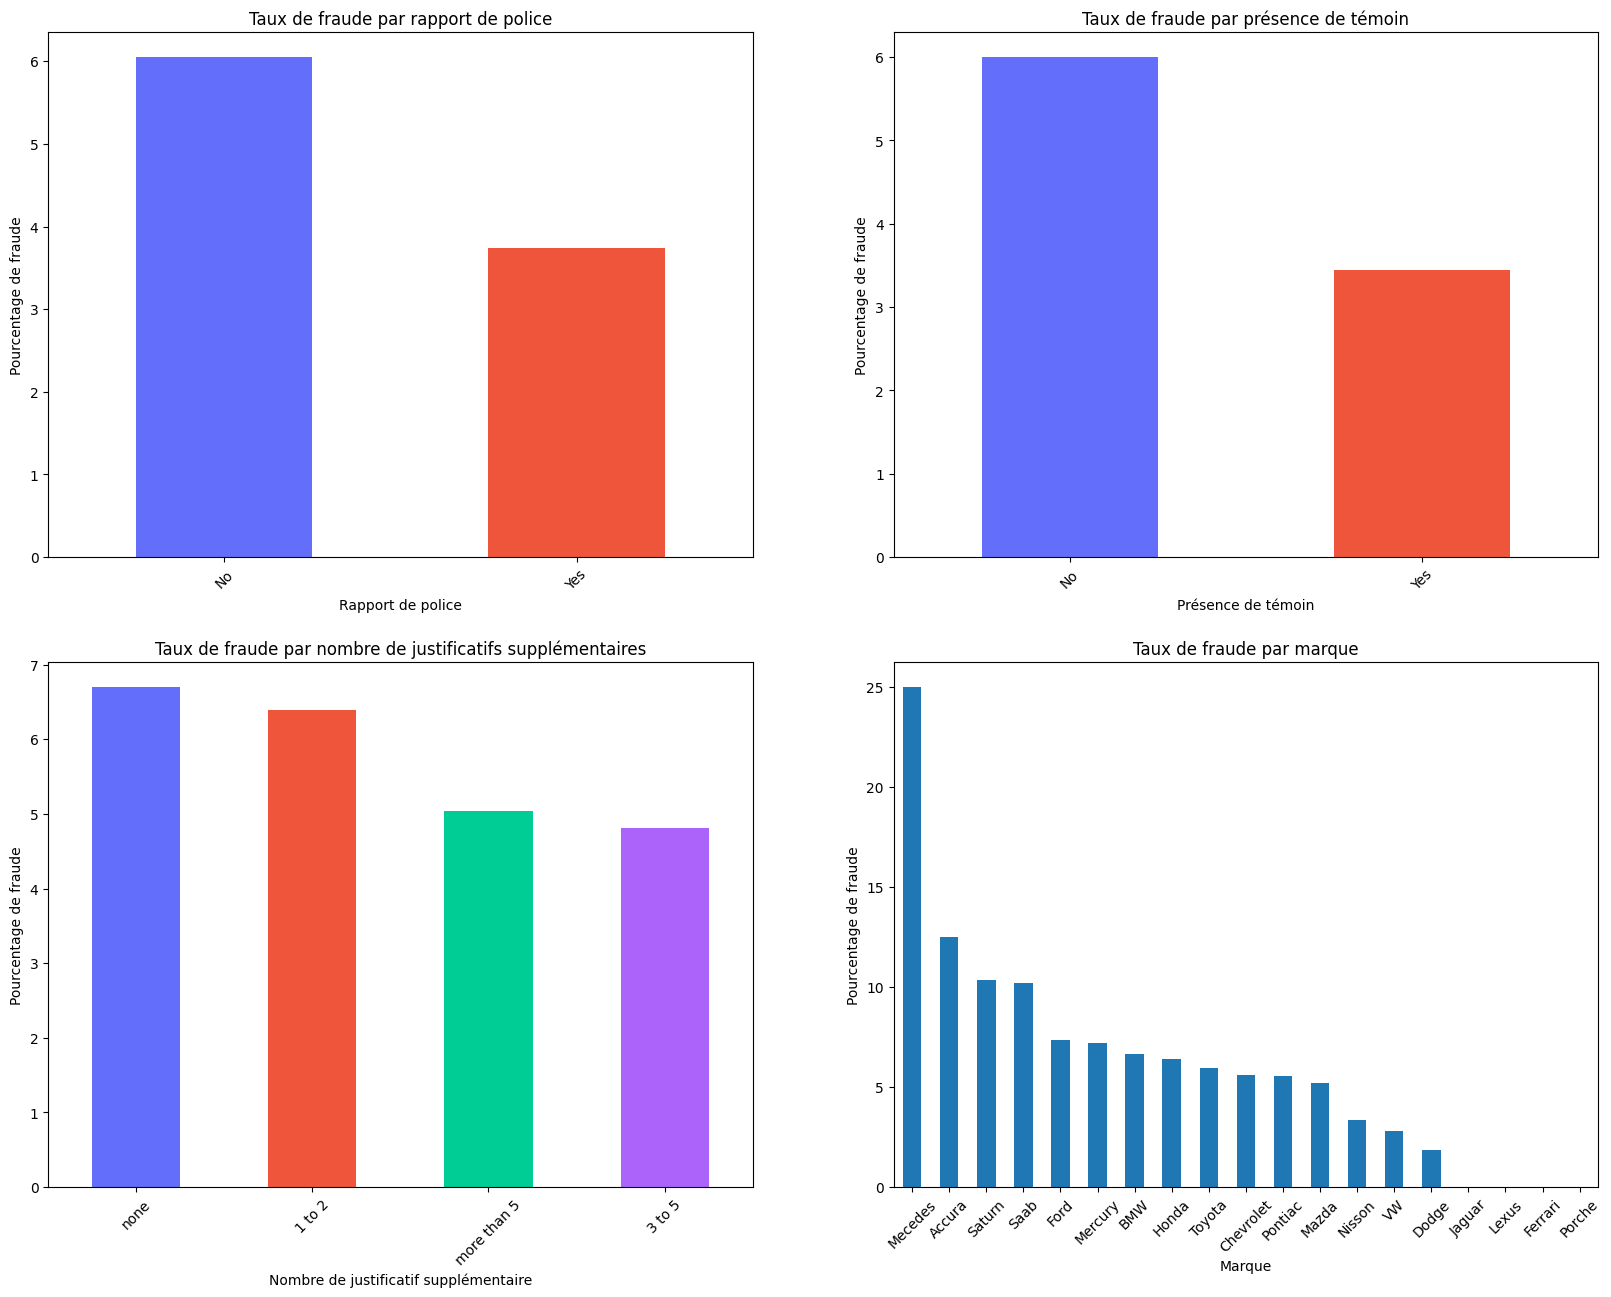

In [30]:
# PoliceReportFiled
plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
fraud_rate = (
    df.groupby("PoliceReportFiled")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar",color= ['#636EFA', '#EF553B'])
plt.title("Taux de fraude par rapport de police")
plt.xlabel("Rapport de police")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# WitnessPresent

plt.subplot(2, 2, 2)
fraud_rate = (
    df.groupby("WitnessPresent")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B', ])
plt.title("Taux de fraude par présence de témoin")
plt.xlabel("Présence de témoin")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

# NumberOfSuppliments
plt.subplot(2, 2, 3)
fraud_rate = (
    df.groupby("NumberOfSuppliments")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar", color= ['#636EFA', '#EF553B',  '#00CC96', '#AB63FA'])
plt.title("Taux de fraude par nombre de justificatifs supplémentaires")
plt.xlabel("Nombre de justificatif supplémentaire")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)


plt.subplot(2, 2, 4)
fraud_rate = (
    df.groupby("Make")["FraudFound_P"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
fraud_rate.plot(kind="bar")
plt.title("Taux de fraude par marque")
plt.xlabel("Marque")
plt.ylabel("Pourcentage de fraude")
plt.xticks(rotation=45)

## Split des données entrainement et de test

In [ ]:
# Séparation label et features
X = df.drop(columns=["PolicyNumber", "RepNumber", "FraudFound_P"])
y = df["FraudFound_P"]


# Séparation des données d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_colums = X_train.select_dtypes(include=np.number).columns
cat_colums = X_train.select_dtypes(include=str).columns

print(f"num_colums {len(num_colums)}")
print(f"cat_colums {len(cat_colums)}")
print(y_test.shape)
print(y_train.shape)


num_colums 6
cat_colums 24
(3084,)
(12336,)


## Utilisation des pipelines pour le preprocessing

### Liste des colonnes

In [39]:
numeric_columns = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating', 'Year']
age_column = ['Age'] # Imputer special pour age
make_column = ["Make"]
categoric_one_hot_columns = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", 
                             "VehicleCategory", "AgentType", "BasePolicy","PoliceReportFiled","WitnessPresent"]
categoric_ordinal_columns = ["NumberOfCars", "VehiclePrice", "Days_Policy_Claim", 
                    "Days_Policy_Accident", "PastNumberOfClaims", "AgeOfVehicle", 
                    "AgeOfPolicyHolder", "AddressChange_Claim", "Month", "DayOfWeek", "DayOfWeekClaimed", "MonthClaimed", "NumberOfSuppliments"]



### Pipeline pour les colonnes numériques

In [40]:
numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer()),('scaler', StandardScaler())])
age_numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(missing_values=0, strategy='median')),('scaler', StandardScaler()) ])


### Pipeline pour l'encodage des variables catégorielles


In [ ]:
#OneHotEncoder
categoric_one_hot_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')) ])

#OrdinalEncoder

NumberOfCars_order = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
VehiclePrice_order = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
Days_Policy_Claim_order= ['none', '8 to 15', '15 to 30','more than 30' ]
Days_Policy_Accident_order= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
PastNumberOfClaims_order= ['none', '1', '2 to 4', 'more than 4']
AgeOfVehicle_order= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
AgeOfPolicyHolder_order= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
AddressChange_Claim_order= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
Month_order= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
DayOfWeek_order= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
DayOfWeekClaimed_order= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
MonthClaimed_order= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
NumberOfSuppliments_order = ['none','1 to 2', '3 to 5','more than 5'  ]


ordinal_encoder_pipe = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent')),
                                   ("encoder", OrdinalEncoder(
            categories=[
                NumberOfCars_order, 
                VehiclePrice_order, 
                Days_Policy_Claim_order,
                Days_Policy_Accident_order,
                PastNumberOfClaims_order,
                AgeOfVehicle_order,
                AgeOfPolicyHolder_order,
                AddressChange_Claim_order,
                Month_order,
                DayOfWeek_order,
                DayOfWeekClaimed_order,
                MonthClaimed_order,
                NumberOfSuppliments_order
            ]
        )
    ) 
])

# Target encoder
make_categoric_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('encoder', TargetEncoder(target_type="auto")) ])

### Utilisation du columnTranformer

In [49]:
preprocessor = ColumnTransformer([
    
    ("num", numeric_pipe, numeric_columns),

    ("age", age_numeric_pipe, age_column),


    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

## Modèle Baseline
La régression logistique est utilisée comme baseline car elle fournit un modèle rapide et interprétable pour une tâche de classification binaire. Elle permet d’établir un premier niveau de performance avant de comparer des modèles plus complexes capables de capturer des relations non linéaires.


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.99      0.60      0.74      2899
           1       0.13      0.91      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.61      0.71      3084



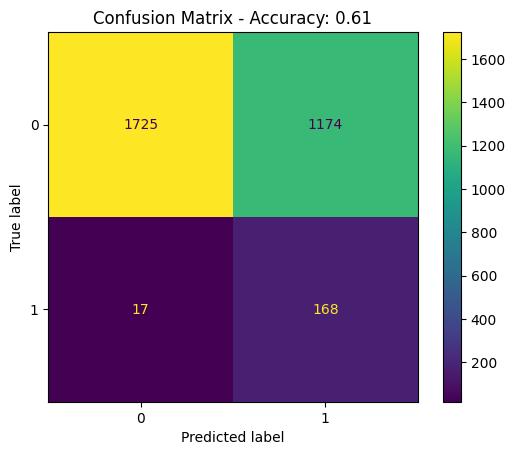

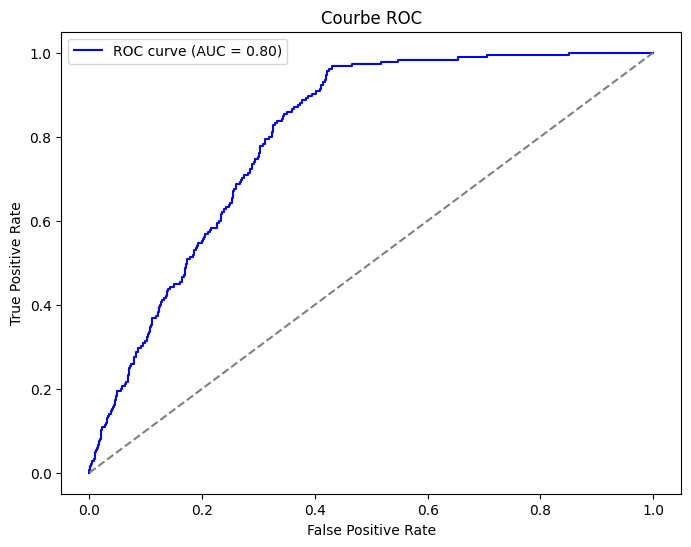

In [ ]:
# Regression Logistique

print("\nCréation du pipeline avec préprocessing et modèle...")
pipeline_logReg = Pipeline([
    ('preprocessor', preprocessor),                  
    ('logistic', LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'))              # Modèle de régression logistique
])



# Entrainement et prédiction du modèle
pipeline_logReg.fit(X_train, y_train)
y_pred = pipeline_logReg.predict(X_test)

# probabilities
y_prob = pipeline_logReg.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

## Modele RandomForest


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       1.00      0.02      0.03       185

    accuracy                           0.94      3084
   macro avg       0.97      0.51      0.50      3084
weighted avg       0.94      0.94      0.91      3084



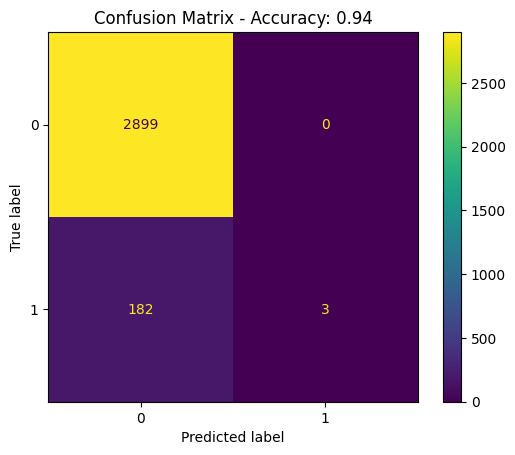

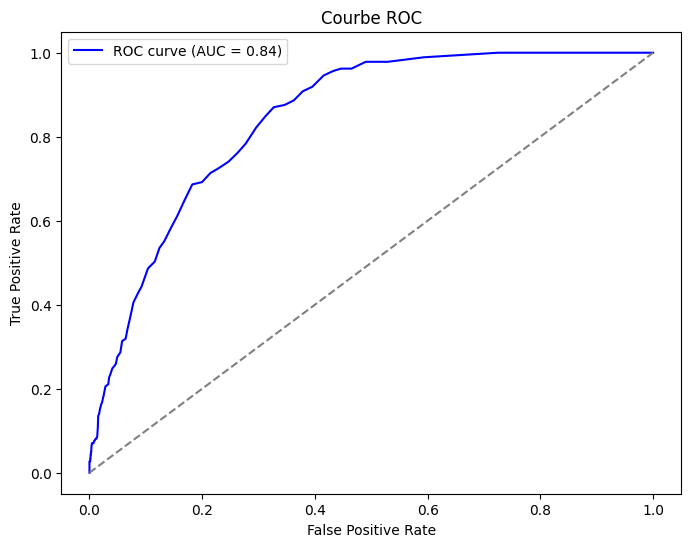

In [51]:
# Modele RandomForest
print("\nCréation du pipeline avec préprocessing et modèle...")


random_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),
    
    ("make", make_categoric_pipe, make_column)
])

pipeline_random = Pipeline([
    ('preprocessor', random_preprocessor),                  # Proprcessor
    ('random', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200,))              # Modèle de foret aléatoire
])

# Entrainement et prédiction du modèle
pipeline_random.fit(X_train, y_train)
y_pred = pipeline_random.predict(X_test)

# probabilities
y_prob = pipeline_random.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# Ne détecte pratiquement pas les cas de fraude. Car le recall est de 0.01 => Detecte 2 cas de fraude sur 185
# Donc risque de ne pas retenir ce modèle. Pour les cas de ce type de fraude , c'est probalement très couteux de
# ne pas detecter les fraudes. Donc un modèle qui detecte mieux les fraudes est préférables dans notre cas.

## Modèle Boost
Modèle utilise est CatBoost car le dataset contient beaucoup de features catégorielles


Création du pipeline avec préprocessing et modèle CatBoost...
Learning rate set to 0.248809
0:	learn: 0.5764417	total: 58.7ms	remaining: 5.82s
1:	learn: 0.5273752	total: 67.5ms	remaining: 3.31s
2:	learn: 0.5073704	total: 73.9ms	remaining: 2.39s
3:	learn: 0.4941143	total: 82ms	remaining: 1.97s
4:	learn: 0.4775389	total: 88.4ms	remaining: 1.68s
5:	learn: 0.4705078	total: 95.4ms	remaining: 1.5s
6:	learn: 0.4657554	total: 104ms	remaining: 1.38s
7:	learn: 0.4598662	total: 111ms	remaining: 1.28s
8:	learn: 0.4560619	total: 118ms	remaining: 1.19s
9:	learn: 0.4528027	total: 126ms	remaining: 1.13s
10:	learn: 0.4485750	total: 132ms	remaining: 1.07s
11:	learn: 0.4463874	total: 138ms	remaining: 1.01s
12:	learn: 0.4410916	total: 143ms	remaining: 955ms
13:	learn: 0.4377077	total: 148ms	remaining: 908ms
14:	learn: 0.4286354	total: 153ms	remaining: 867ms
15:	learn: 0.4272778	total: 158ms	remaining: 829ms
16:	learn: 0.4114250	total: 169ms	remaining: 824ms
17:	learn: 0.4083053	total: 179ms	remaining: 81

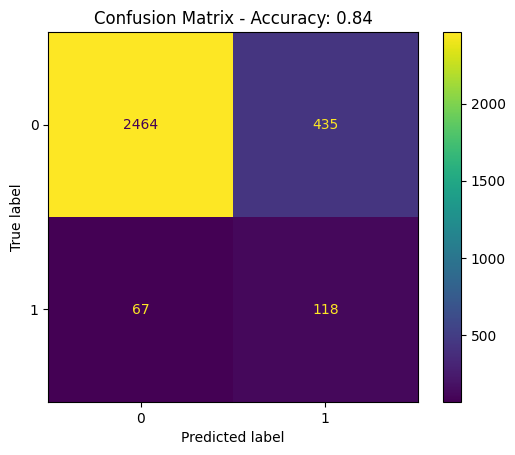

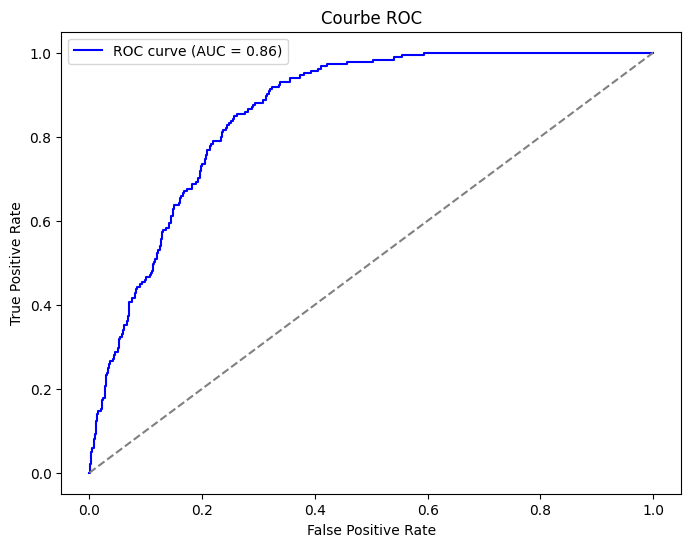

In [52]:
# Modele XGBoost
print("\nCréation du pipeline avec préprocessing et modèle CatBoost...")


boost_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

pipeline_boost = Pipeline([
    ('preprocessor', boost_preprocessor),                  # Proprcessor
    ('boosting', CatBoostClassifier(iterations=100, auto_class_weights='Balanced'))              # Modèle Boost
])

# Entrainement et prédiction du modèle
pipeline_boost.fit(X_train, y_train)
y_pred = pipeline_boost.predict(X_test)

# probabilities
y_prob = pipeline_boost.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()


# Calcul de la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label="ROC curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_prob)))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

Après une première phase d’évaluation, deux modèles ont été retenus pour approfondissement : Logistic Regression et CatBoost. Ces modèles présentent les meilleurs résultats sur la classe minoritaire (fraude). Une phase de tuning est ensuite réalisée afin d’évaluer leur potentiel réel et d’identifier le meilleur compromis entre détection des fraudes et limitation des faux positifs.

- GridSearchCV : teste toutes les combinaisons

- RandomizedSearchCV : teste un nombre limité de combinaisons aléatoires - si la grille est trop grande

In [53]:
# GridSearchCV sur moèle RegressionLogistic

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
}

print(pipeline_logReg.get_params().keys())
logRegSearch = GridSearchCV(pipeline_logReg, param_grid=params, cv=cv, scoring='roc_auc', n_jobs=-1)
logRegSearch.fit(X_train, y_train)
print(f"Best parameters: {logRegSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'logistic', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__scaler', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__num__scaler__copy', 'preprocessor__num__scaler__with_mean', 'preprocessor__nu

In [54]:
# RandomizedSearchCV sur moèle RandomForest

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'random__n_estimators': [10, 50, 100],
    'random__max_depth': [None, 10, 20, 50],
    'random__max_features': [2, 5],
    'random__min_samples_leaf': [1, 2, 4]
}

print(pipeline_random.get_params().keys())
randomSearch = RandomizedSearchCV(pipeline_random, param_distributions=params, n_iter=30, cv=cv, scoring='roc_auc', n_jobs=-1,  random_state=42)
#randomSearch = GridSearchCV(pipeline_random, param_grid=parms, cv=cv, scoring='roc_auc', n_jobs=-1)
randomSearch.fit(X_train, y_train)
print(f"Best parameters: {randomSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'random', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__age__memory', 'preprocessor__age__steps', 'preprocessor__age__transform_input', 'preprocessor__age__verbose'

In [ ]:
# RandomizedSearchCV sur moèle CatBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'boosting__depth': [4,5,6,7,8,9, 10],
    'boosting__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'boosting__iterations': [10, 20,30,40,50,60,70,80,90, 100]
}

print(pipeline_boost.get_params().keys())
boostingSearch = RandomizedSearchCV(pipeline_boost, param_distributions=params, cv=cv, n_iter=30,scoring='roc_auc', n_jobs=-1, random_state=42)
boostingSearch.fit(X_train, y_train)
print(f"Best parameters: {boostingSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'boosting', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__onehot__memory', 'preprocessor__onehot__steps', 'preprocessor__onehot__transform_input', 'preprocessor__onehot__verbose', 'preprocessor__onehot__oneh

## Choisir le meilleur modèle

                 Model  Accuracy    Recall        F1   ROC-AUC
2             CatBoost  0.679637  0.940541  0.260479  0.857500
1        Random Forest  0.904669  0.264865  0.250000  0.828219
0  Logistic Regression  0.608949  0.924324  0.220930  0.803966


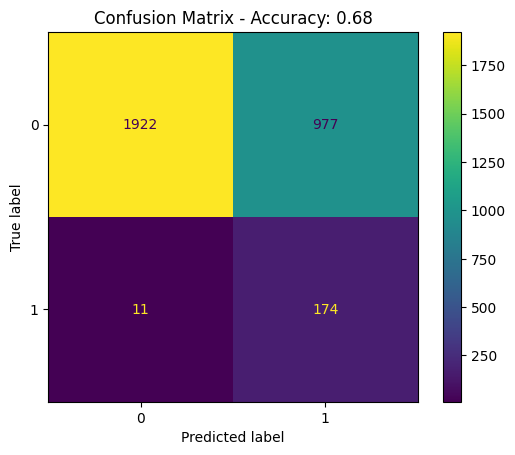

In [ ]:
best_logreg = logRegSearch.best_estimator_
best_random = randomSearch.best_estimator_
best_boost = boostingSearch.best_estimator_

models = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_random,
    "CatBoost" : best_boost
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(df_results)

# Modèle CatBosst meilleur candidat.
y_pred = best_boost.predict(X_test)
y_proba = best_boost.predict_proba(X_test)[:, 1]
acc= accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=confusion).plot()
plt.title(f"Confusion Matrix - Accuracy: {acc:.2f}")
plt.show()




Après optimisation des hyperparamètres, CatBoost devient le modèle le plus performant. Il obtient le meilleur Recall (94.1 %), le meilleur F1-score (0.260) ainsi que le meilleur ROC-AUC (0.857). Ces résultats indiquent que CatBoost est plus efficace pour détecter les cas de fraude.

In [ ]:
thresholds = [ 0.5, 0.6, 0.7, 0.8]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2899
           1       0.19      0.56      0.28       185

    accuracy                           0.83      3084
   macro avg       0.58      0.70      0.59      3084
weighted avg       0.92      0.83      0.86      3084


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2899
           1       0.21      0.50      0.30       185

    accuracy                           0.86      3084
   macro avg       0.59      0.69      0.61      3084
weighted avg       0.92      0.86      0.89      3084


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      2899
           1       0.26      0.36      0.30       185

    accuracy                           0.90      3084
   macro avg       0.61      0.65      0.62      3084
weighted avg       0.92   

                                 Feature  Importance
14           onehot__Fault_Policy Holder   25.607052
15             onehot__Fault_Third Party    9.186820
5                              num__Year    8.032038
32          onehot__BasePolicy_Liability    7.730201
18  onehot__PolicyType_Sedan - Liability    6.888068
41                       ordinale__Month    6.019982
40         ordinale__AddressChange_Claim    5.150786
3                        num__Deductible    4.503778
44                ordinale__MonthClaimed    4.236754
0                       num__WeekOfMonth    2.453581


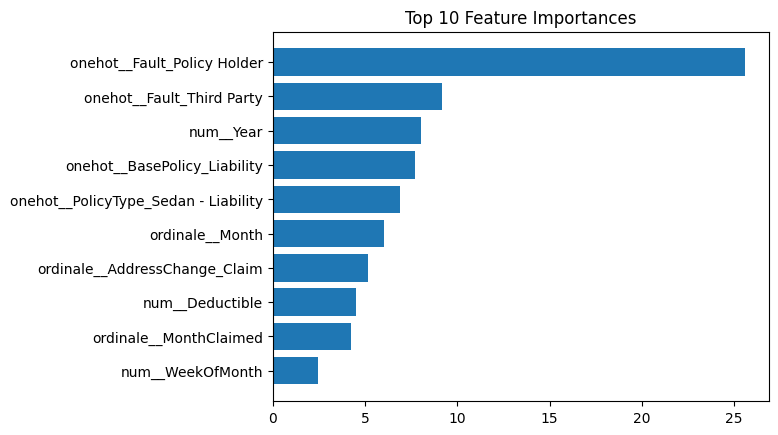

In [ ]:
best_boost = boostingSearch.best_estimator_
rf_model = best_boost.named_steps['boosting']
importances = rf_model.feature_importances_
feature_names = best_boost.named_steps['preprocessor'].get_feature_names_out()
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances.head(10))

import matplotlib.pyplot as plt

top10 = feature_importances.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

Certaines variables, notamment liées à la notion de responsabilité ("Fault"), présentent une importance élevée dans le modèle.

Cependant, la documentation du dataset ne précise pas clairement à quel moment ces informations sont disponibles dans le processus métier.

Il existe donc un risque potentiel de data leakage si ces variables sont déterminées après investigation du sinistre.

En l’absence d’information complémentaire sur le dataset Kaggle, cette hypothèse ne peut pas être confirmée.